## F1-2025 Season Analysis ##

![alt text](images/f1_logo.png)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
from matplotlib.patches import Patch
from matplotlib.patches import Rectangle
import seaborn as sns
import math

In [3]:
RaceCalendar = pd.read_csv('csv/Formula1_2025Season_calendar.csv')
RaceCalendar.set_index('Round', inplace=True)
Drivers = pd.read_csv('csv/Formula1_2025Season_drivers.csv')
Drivers.set_index('Abbreviation', inplace=True)
Teams = pd.read_csv('csv/Formula1_2025Season_teams.csv')
Teams.index = range(1,11)
QualifyingResults = pd.read_csv('csv/Formula1_2025Season_qualifyingResults.csv')
SprintRaceResults = pd.read_csv('csv/Formula1_2025Season_sprintResults.csv')
RaceResults = pd.read_csv('csv/Formula1_2025Season_raceResults.csv')
DotdVotes = pd.read_csv('csv/Formula1_2025Season_driverOfTheDayVotes.csv')
DotdVotes.set_index('Track', inplace=True)

### 2025 Season Race Calendar

In [4]:
RaceCalendar

,Race Date,GP Name,Country,City,Circuit Name,First GP,Number of Laps,Circuit Length(km),Race Distance(km),Lap Record,Record Owner,Record Year,Turns,DRS Zones
Round,,,,,,,,,,,,,,
1,16/03/2025,Louis Vuitton Australian Grand Prix,Australia,Melbourne,Albert Park Circuit,1996,58,5.278,306.124,1:19.813,Charles Leclerc,2024,14,4
2,23/03/2025,Heineken Chinese Grand Prix,China,Shanghai,Shanghai International Circuit,2004,56,5.451,305.066,1:32.238,Michael Schumacter,2004,16,2
3,06/04/2025,Lenovo Japanese Grand Prix,Japan,Suzuka,Suzuka Circuit,1987,53,5.807,307.471,1:30.965,Kimi Antonelli,2025,18,1
4,13/04/2025,Gulf Air Bahrain Grand Prix,Bahrain,Sakhir,Bahrain International Circuit,2004,57,5.412,308.238,1:31.447,Pedro de la Rosa,2005,15,3
5,20/04/2025,STC Saudi Arabian Grand Prix,Saudi Arabia,Jeddah,Jeddah Corniche Circuit,2021,50,6.174,308.450,1:30.734,Lewis Hamilton,2021,27,3
6,04/05/2025,Crypto.com Miami Grand Prix,United States,Miami,Miami International Autodrome,2022,57,5.412,308.326,1:29.708,Max Verstappen,2023,19,3
7,18/05/2025,AWS Gran Premio Del Made in Italy e Dell'Emili...,Italy,Imola,Autodromo Internazionale Enzo e Dino Ferrari,1980,63,4.909,309.049,1:15.484,Lewis Hamilton,2020,19,1
8,25/05/2025,Tag Heuer Grand Prix de Monaco,Monaco,Monaco,Circuit de Monaco,1950,78,3.337,260.286,1:12.909,Lewis Hamilton,2021,19,1
9,01/06/2025,Aramco Gran Premio de España,Spain,Barcelona,Circuit de Barcelona-Catalunya,1991,66,4.657,307.236,1:15.743,Oscar Piastri,2025,14,2


### 2025 Season - Teams

In [5]:
Teams

,Team,Full Team Name,Base,Team Chief,Technical Chief,Chassis,Power Unit,First Team Entry,Grand Prix Entered,Team Points,Highest Race Finish,Podiums,Highest Grid Position,Pole Positions,World Championships
1,McLaren,McLaren Formula 1 Team,"Woking, United Kingdom",Andrea Stella,Peter Prodromou / Neil Houldey,MCL39,Mercedes,1966,995,7783.5,1(x203),445,1(x177),177,10
2,Mercedes,Mercedes-AMG Petronas Formula One Team,"Brackley, United Kingdom",Toto Wolff,James Allison,W16,Mercedes,1970,329,8159.5,1(x122),201,1(x136),135,8
3,Red Bull Racing,Oracle Red Bull Racing,"Milton Keynes, United Kingdom",Laurent Mekies,Pierre Waché,RB21,Honda RBPT,1997,418,8288.0,1(x130),233,1(x111),111,6
4,Ferrari,Scuderia Ferrari HP,"Maranello, Italy",Frédéric Vasseur,Loic Serra / Enrico Gualtieri,SF-25,Ferrari,1950,1123,10675.0,1(x249),639,1(x254),254,16
5,Williams,Atlassian Williams Racing,"Grove, United Kingdom",James Vowles,Pat Fry,FW47,Mercedes,1978,851,3768.0,1(x114),245,1(x128),128,9
6,Racing Bulls,Visa Cash App Racing Bulls Formula One Team,"Faenza, Italy",Alan Permane,Tim Goss,VCARB 02,Honda RBPT,1985,399,947.0,1(x2),6,1(x1),1,0
7,Aston Martin,Aston Martin Aramco Formula One Team,"Silverstone, United Kingdom",Andy Cowell,Enrico Cardile,AMR25,Mercedes,2018,152,863.0,1(x1),12,1(x1),1,0
8,Haas F1 Team,MoneyGram Haas F1 Team,"Kannapolis, United States",Ayao Komatsu,Andrea De Zordo,VF-25,Ferrari,2016,214,386.0,4(x2),0,4(x1),1,0
9,Kick Sauber,Stake F1 Team Kick Sauber,"Hinwil, Switzerland",Jonathan Wheatley,James Key,C45,Ferrari,1993,615,1088.0,1(x1),27,1(x1),1,0
10,Alpine,BWT Alpine Formula One Team,"Enstone, United Kingdom",Flavio Briatore,David Sanchez,A525,Renault,1986,392,2000.0,1(x21),60,1(x20),20,2


### 2025 Season - Drivers

In [6]:
Drivers

,Driver,Race Number,Team,Country,Grand Prix Entered,Career Points,Highest Race Finish,Podiums,Highest Grid Position,Pole Positions,World Championships,DNFs,Date of Birth,Place of Birth
Abbreviation,,,,,,,,,,,,,,
NOR,Lando Norris,4,McLaren,United Kingdom,152,1430.0,1(x11),44,1(x16),16,1,13,13/11/1999,"Bristol, England"
PIA,Oscar Piastri,81,McLaren,Australia,70,799.0,1(x9),26,1(x6),6,0,4,06/04/2001,"Melbourne, Victoria"
RUS,George Russell,63,Mercedes,United Kingdom,152,1033.0,1(x5),24,1(x8),7,0,19,15/02/1998,"King's Lynn, England"
ANT,Kimi Antonelli,12,Mercedes,Italy,24,150.0,2(x1),3,2(x1),0,0,4,25/08/2006,"Bologna, Italy"
VER,Max Verstappen,1,Red Bull Racing,Netherlands,233,3444.5,1(x71),127,1(x48),48,4,33,30/09/1997,"Hasselt, Belgium"
TSU,Yuki Tsunoda,22,Red Bull Racing,Japan,111,124.0,4(x1),0,3(x1),0,0,15,11/05/2000,"Sagamihara, Japan"
LEC,Charles Leclerc,16,Ferrari,Monaco,171,1672.0,1(x8),50,1(x27),27,0,23,16/10/1997,"Monte Carlo, Monaco"
HAM,Lewis Hamilton,44,Ferrari,United Kingdom,380,5018.5,1(x105),202,1(x104),104,7,34,07/01/1985,"Stevenage, England"
ALB,Alexander Albon,23,Williams,Thailand,128,313.0,3(x2),2,4(x5),0,0,22,23/03/1996,"London, England"


In [7]:
RaceResults.head(10)

,Track,Position,No,Driver,Team,Starting Grid,Laps,Time/Retired,Points,Set Fastest Lap,Fastest Lap Time
0,Australia,1,4,Lando Norris,McLaren Mercedes,1,57,1:42:06.304,25,Yes,1:22.167
1,Australia,2,1,Max Verstappen,Red Bull Racing Honda RBPT,3,57,+0.895,18,No,1:23.081
2,Australia,3,63,George Russell,Mercedes,4,57,+8.481,15,No,1:25.065
3,Australia,4,12,Kimi Antonelli,Mercedes,16,57,+10.135,12,No,1:24.901
4,Australia,5,23,Alexander Albon,Williams Mercedes,6,57,+12.773,10,No,1:24.597
5,Australia,6,18,Lance Stroll,Aston Martin Aramco Mercedes,13,57,+17.413,8,No,1:25.538
6,Australia,7,27,Nico Hulkenberg,Kick Sauber Ferrari,17,57,+18.423,6,No,1:25.243
7,Australia,8,16,Charles Leclerc,Ferrari,7,57,+19.826,4,No,1:25.271
8,Australia,9,81,Oscar Piastri,McLaren Mercedes,2,57,+20.448,2,No,1:23.242
9,Australia,10,44,Lewis Hamilton,Ferrari,8,57,+22.473,1,No,1:24.218


In [8]:
SprintRaceResults

,Track,Position,No,Driver,Team,Starting Grid,Laps,Time/Retired,Points
0,China,1,44,Lewis Hamilton,Ferrari,1,19,30:39.965,8
1,China,2,81,Oscar Piastri,McLaren Mercedes,3,19,+6.889,7
2,China,3,1,Max Verstappen,Red Bull Racing Honda RBPT,2,19,+9.804,6
3,China,4,63,George Russell,Mercedes,5,19,+11.592,5
4,China,5,16,Charles Leclerc,Ferrari,4,19,+12.190,4
...,...,...,...,...,...,...,...,...,...
115,Qatar,16,27,Nico Hulkenberg,Kick Sauber Ferrari,14,19,+39.638,0
116,Qatar,17,44,Lewis Hamilton,Ferrari,18,19,+46.171,0
117,Qatar,18,10,Pierre Gasly,Alpine Renault,19,19,+69.534,0
118,Qatar,19,18,Lance Stroll,Aston Martin Aramco Mercedes,17,19,+77.960,0


### 2025 Season - Driver Standings

In [9]:
racePoints = RaceResults.groupby(['Driver'])['Points'].sum().sort_values(ascending=False)
sprintRacePoints = SprintRaceResults.groupby(['Driver'])['Points'].sum().sort_values(ascending=False)
for driver in RaceResults['Driver'].unique():
    if driver not in SprintRaceResults['Driver'].unique():
        sprintRacePoints.loc[driver] = 0
driverStandings = (racePoints + sprintRacePoints).fillna(0).sort_values(ascending=False)
driverStandings = pd.DataFrame(driverStandings).reset_index()
driverStandings['POS'] = range(1, len(driverStandings) + 1)
driverStandings['Points'] = driverStandings['Points'].astype(int)

driverTeams = (RaceResults.groupby('Driver')['Team'].last())

driverStandings['Team'] = driverStandings['Driver'].map(driverTeams)
driverStandings.set_index('POS', inplace=True)
driverStandings

,Driver,Points,Team
POS,,,
1,Lando Norris,423,McLaren Mercedes
2,Max Verstappen,421,Red Bull Racing Honda RBPT
3,Oscar Piastri,410,McLaren Mercedes
4,George Russell,319,Mercedes
5,Charles Leclerc,242,Ferrari
6,Lewis Hamilton,156,Ferrari
7,Kimi Antonelli,150,Mercedes
8,Alexander Albon,73,Williams Mercedes
9,Carlos Sainz,64,Williams Mercedes


In [10]:
team_colors = {
    'McLaren Mercedes': '#FF8000',
    'Red Bull Racing Honda RBPT': '#3671C6',
    'Ferrari': '#E80020',
    'Mercedes': '#27F4D2',
    'Williams Mercedes': '#64C4FF',
    'Aston Martin Aramco Mercedes': '#229971',
    'Alpine Renault': '#FF87BC',
    'Haas Ferrari': '#B6BABD',
    'Racing Bulls Honda RBPT': '#6692FF',
    'Kick Sauber Ferrari': '#52E252'
}

In [11]:
driverStandings['Color'] = driverStandings['Team'].map(team_colors)

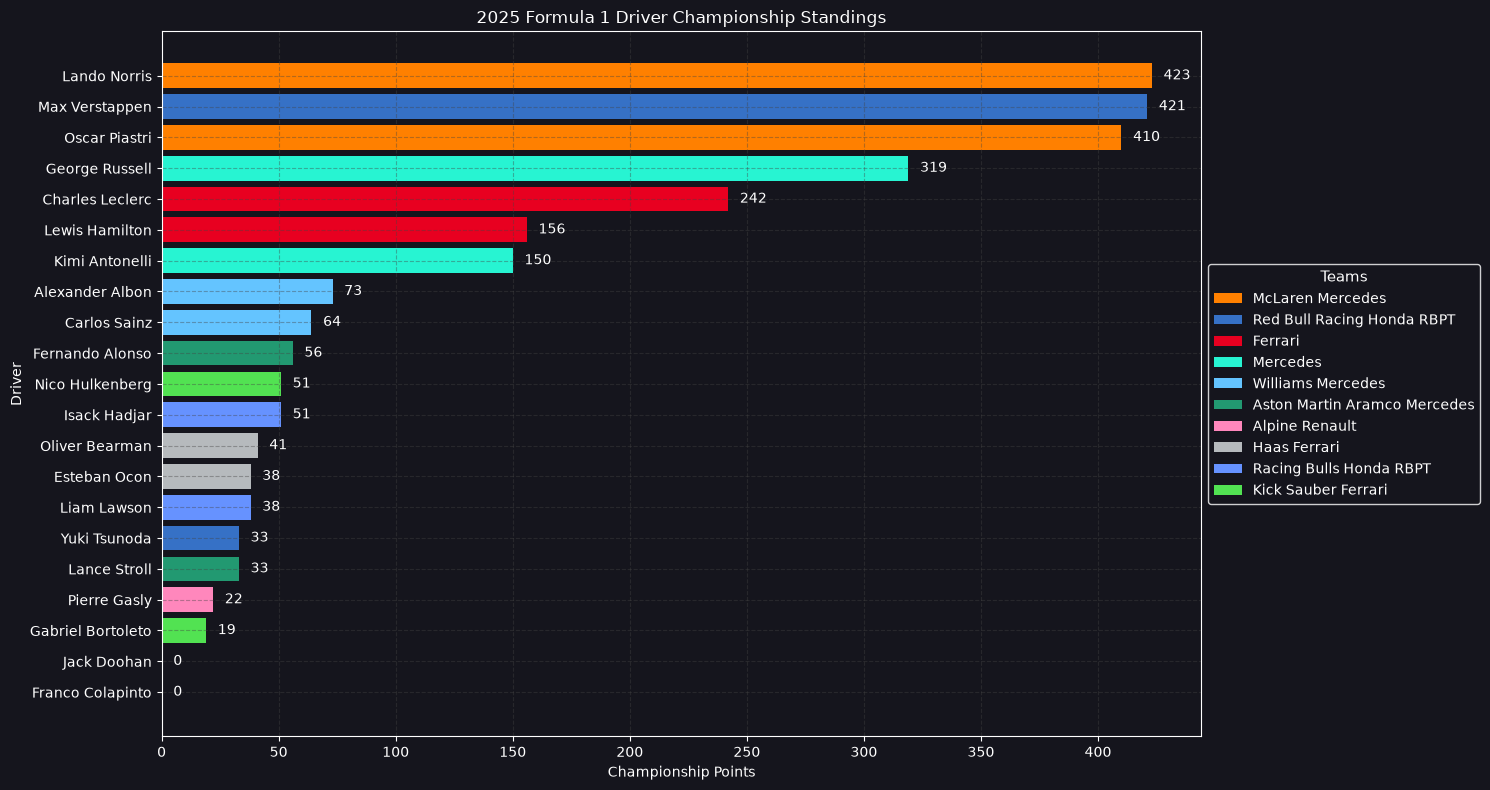

In [12]:
plt.rcParams['axes.facecolor'] = '#15151d'
plt.rcParams['figure.facecolor'] = '#15151d'
plt.rcParams['grid.color'] = '#444444'

plt.figure(figsize=(15, 8))

ax = plt.gca()
ax.set_facecolor('#15151d')

bars = plt.barh(driverStandings['Driver'], driverStandings['Points'], color=driverStandings['Color'])

plt.xlabel('Championship Points', color='white')
plt.ylabel('Driver', color='white')
plt.title('2025 Formula 1 Driver Championship Standings', color='white')
plt.grid(alpha=0.4,  linestyle='--')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

for spine in ax.spines.values():
    spine.set_color('white')

plt.gca().invert_yaxis()

# Point values
for bar in bars:
    points = bar.get_width()

    plt.text(points + 5, bar.get_y() + bar.get_height() / 2, f'{int(points)}', va='center', color='white')

# Create team legend
legend_handles = [
    Patch(facecolor=color, label=team)
    for team, color in team_colors.items()
]

legend = plt.legend(handles=legend_handles, title='Teams', loc='center left', bbox_to_anchor=(1, 0.5), facecolor='#15151d', edgecolor='white', labelcolor='white', title_fontsize=11)
legend.get_title().set_color('white')

plt.tight_layout()
plt.show()

### Point Progression of Top 10 Drivers throught the Season ###

In [13]:
# Top 10 drivers
driverStandingsTop10 = driverStandings['Driver'].head(10).values

# Store race points for each driver
driverPointsTop10 = {}

for driver in driverStandingsTop10:
    driverPointsTop10[driver] = (
        RaceResults[
            RaceResults['Driver'] == driver
        ]['Points'].values.copy()
    )

In [14]:
# Race order
tracks = RaceResults['Track'].unique()

for driver in driverStandingsTop10:

    for track in SprintRaceResults['Track'].unique():

        # Sprint points for this driver at this track
        sprint_points = SprintRaceResults[
            (SprintRaceResults['Driver'] == driver) &
            (SprintRaceResults['Track'] == track)
        ]['Points'].sum()

        # Find the race position using Track
        race_positions = np.where(tracks == track)[0]

        if len(race_positions) > 0:
            position = race_positions[0]

            # Add sprint points to that race
            driverPointsTop10[driver][position] += sprint_points

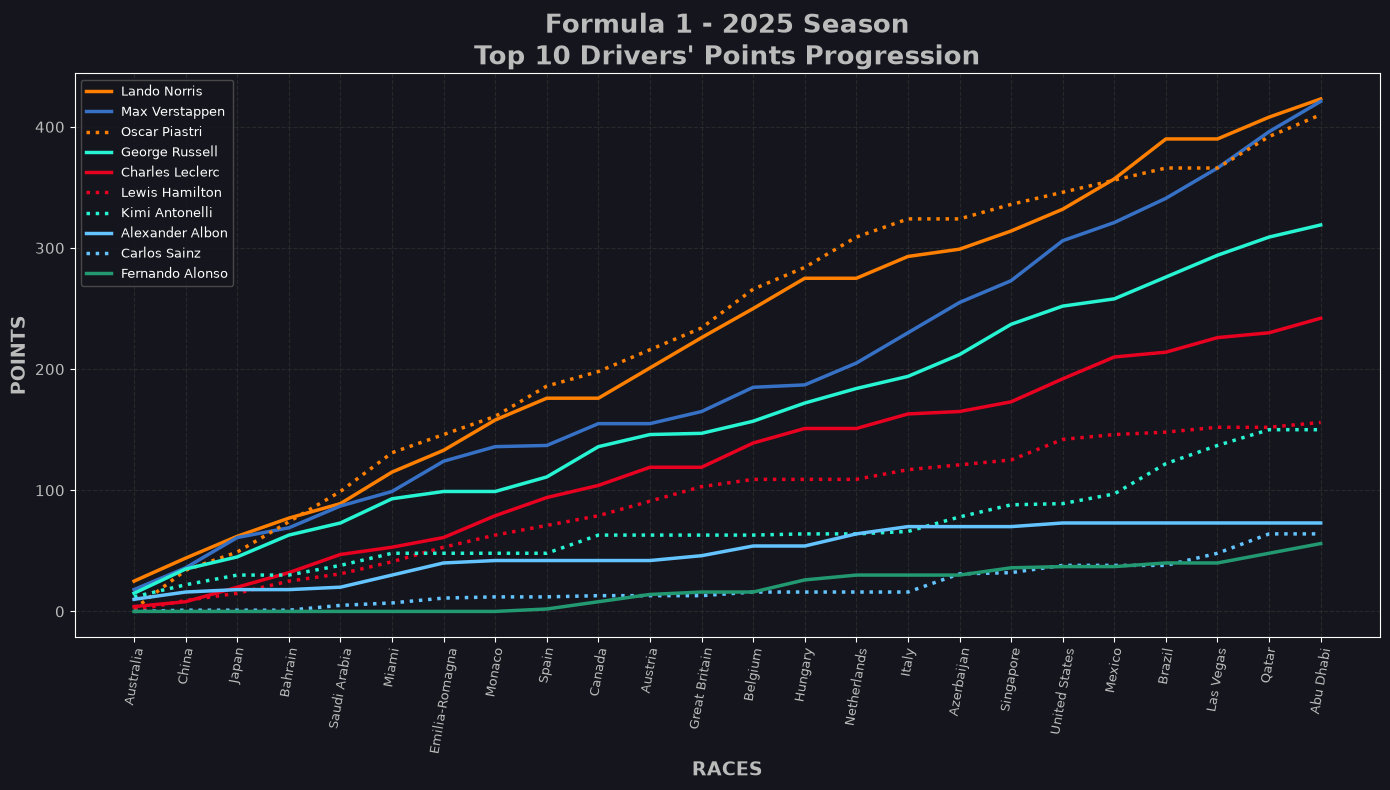

In [15]:
plt.style.use('dark_background')

plt.rcParams['axes.facecolor'] = '#15151d'
plt.rcParams['figure.facecolor'] = '#15151d'
plt.rcParams['grid.color'] = '#444444'

plt.figure(figsize=(14, 8))

team_driver_count = {}

for driver in driverStandingsTop10:

    # Get driver points
    points = driverPointsTop10[driver]

    # Cumulative points
    cumulative_points = np.cumsum(points)

    # Get driver's team
    team = RaceResults[
        RaceResults['Driver'] == driver
    ]['Team'].iloc[0]

    # Get team color
    color = team_colors[team]

    # Count drivers from each team
    if team not in team_driver_count:
        team_driver_count[team] = 0

    team_driver_count[team] += 1

    # First driver = solid
    # Second driver = dotted
    if team_driver_count[team] == 1:
        linestyle = '-'
    else:
        linestyle = ':'

    plt.plot( cumulative_points, label=driver, color=color, linewidth=2.5,linestyle= linestyle)

plt.title("Formula 1 - 2025 Season\nTop 10 Drivers' Points Progression", fontsize=19, fontweight='bold', color='#bbbbbb')

plt.xlabel('RACES', fontsize=14, fontweight='bold', color='#bbbbbb')

plt.ylabel('POINTS', fontsize=14, fontweight='bold', color='#bbbbbb')

plt.xticks(range(len(tracks)), tracks, rotation=80, fontsize=9, color='#bbbbbb')

plt.yticks(fontsize=11, color='#bbbbbb')

plt.grid(alpha=0.4, linestyle='--')

plt.legend(loc='upper left', fontsize=9, frameon=True, facecolor='#15151d', edgecolor='#555555')

plt.tight_layout()
plt.show()

### F1-2025 Season - Constructur Standing ###

In [16]:
racePointsTeam = RaceResults.groupby('Team')['Points'].sum().sort_values(ascending=False)
sprintRacePointsTeam = SprintRaceResults.groupby('Team')['Points'].sum().sort_values(ascending=False)
constructorStandings = (racePointsTeam + sprintRacePointsTeam).fillna(0).sort_values(ascending=False)
constructorStandings = pd.DataFrame(constructorStandings).reset_index()
constructorStandings['POS'] = range(1,11)
constructorStandings.set_index('POS', inplace=True)
constructorStandings

,Team,Points
POS,,
1,McLaren Mercedes,833
2,Mercedes,469
3,Red Bull Racing Honda RBPT,451
4,Ferrari,398
5,Williams Mercedes,137
6,Racing Bulls Honda RBPT,92
7,Aston Martin Aramco Mercedes,89
8,Haas Ferrari,79
9,Kick Sauber Ferrari,70


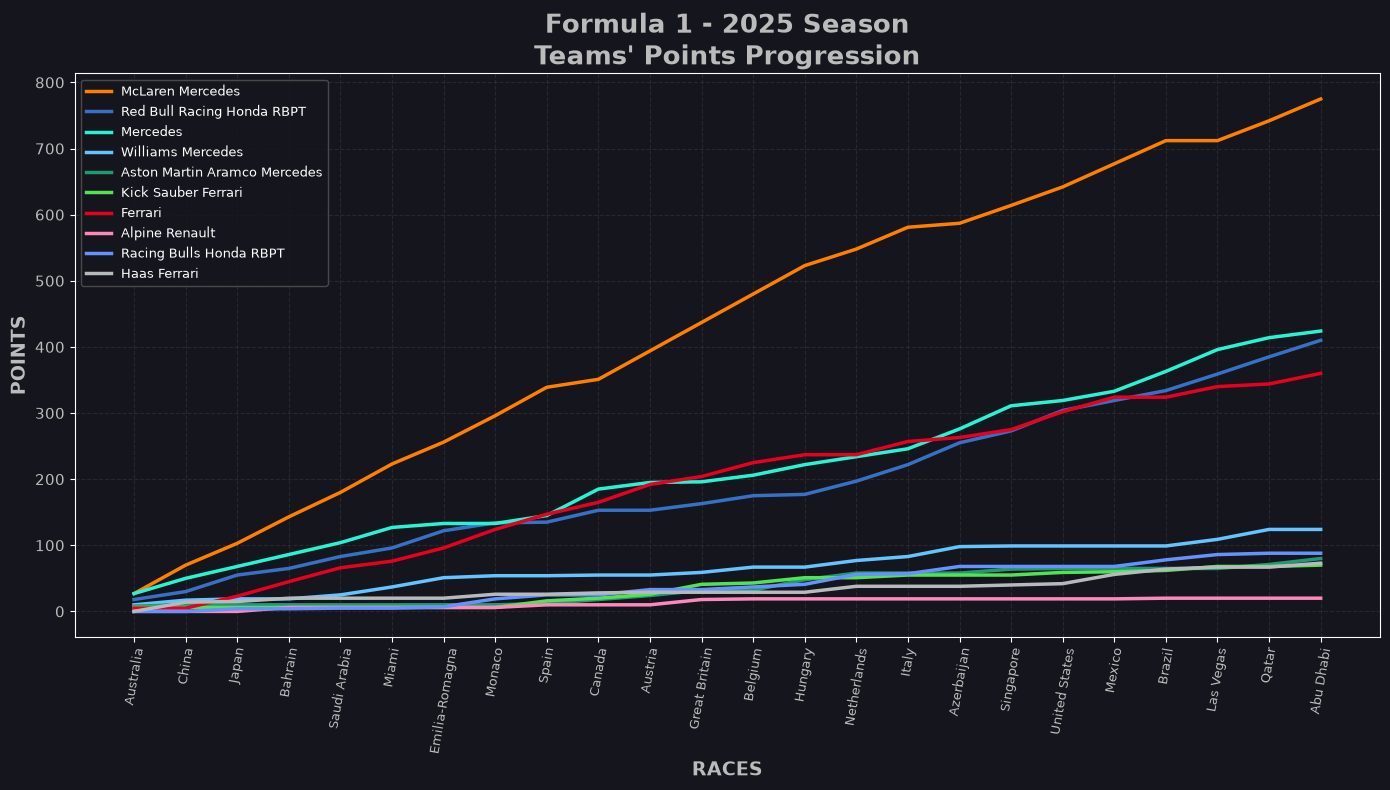

In [17]:
plt.style.use('dark_background')

plt.rcParams['axes.facecolor'] = '#15151d'
plt.rcParams['figure.facecolor'] = '#15151d'
plt.rcParams['grid.color'] = '#444444'

plt.figure(figsize=(14, 8))

# Get teams
teams = RaceResults['Team'].unique()

# Plot each team's progression
for team in teams:

    # Get team's points for each race
    team_points = (
        RaceResults[RaceResults['Team'] == team]
        .groupby('Track')['Points']
        .sum()
        .reindex(tracks, fill_value=0)
        .values
    )

    # Cumulative points
    cumulative_points = np.cumsum(team_points)

    # Team color
    color = team_colors[team]

    plt.plot(cumulative_points,label=team,color=color,linewidth=2.5)


plt.title("Formula 1 - 2025 Season\nTeams' Points Progression",fontsize=19,fontweight='bold',color='#bbbbbb')

plt.xlabel('RACES', fontsize=14, fontweight='bold', color='#bbbbbb')

plt.ylabel( 'POINTS', fontsize=14, fontweight='bold', color='#bbbbbb')

plt.xticks( range(len(tracks)), tracks, rotation=80, fontsize=9, color='#bbbbbb')

plt.yticks( fontsize=11, color='#bbbbbb')

plt.grid( alpha=0.4, linestyle='--')

plt.legend( loc='upper left', fontsize=9, frameon=True, facecolor='#15151d', edgecolor='#555555')

plt.tight_layout()
plt.show()

### 2025 Season - Race Winners ###

In [18]:
race_winners =  RaceResults[RaceResults['Position'] == '1'].drop('Position', axis=1).reset_index(drop=True).rename(index=lambda x: x + 1)
race_winners

,Track,No,Driver,Team,Starting Grid,Laps,Time/Retired,Points,Set Fastest Lap,Fastest Lap Time
1,Australia,4,Lando Norris,McLaren Mercedes,1,57,1:42:06.304,25,Yes,1:22.167
2,China,81,Oscar Piastri,McLaren Mercedes,1,56,1:30:55.026,25,No,1:35.520
3,Japan,1,Max Verstappen,Red Bull Racing Honda RBPT,1,53,1:22:06.983,25,No,1:31.041
4,Bahrain,81,Oscar Piastri,McLaren Mercedes,1,57,1:35:39.435,25,Yes,1:35.140
5,Saudi Arabia,81,Oscar Piastri,McLaren Mercedes,2,50,1:21:06.758,25,No,1:32.228
6,Miami,81,Oscar Piastri,McLaren Mercedes,4,57,1:28:51.587,25,No,1:29.822
7,Emilia-Romagna,1,Max Verstappen,Red Bull Racing Honda RBPT,2,63,1:31:33.199,25,Yes,1:17.988
8,Monaco,4,Lando Norris,McLaren Mercedes,1,78,1:40:33.843,25,Yes,1:13.221
9,Spain,81,Oscar Piastri,McLaren Mercedes,1,66,1:32:57.375,25,Yes,1:15.743
10,Canada,63,George Russell,Mercedes,1,70,1:31:52.688,25,Yes,1:14.119


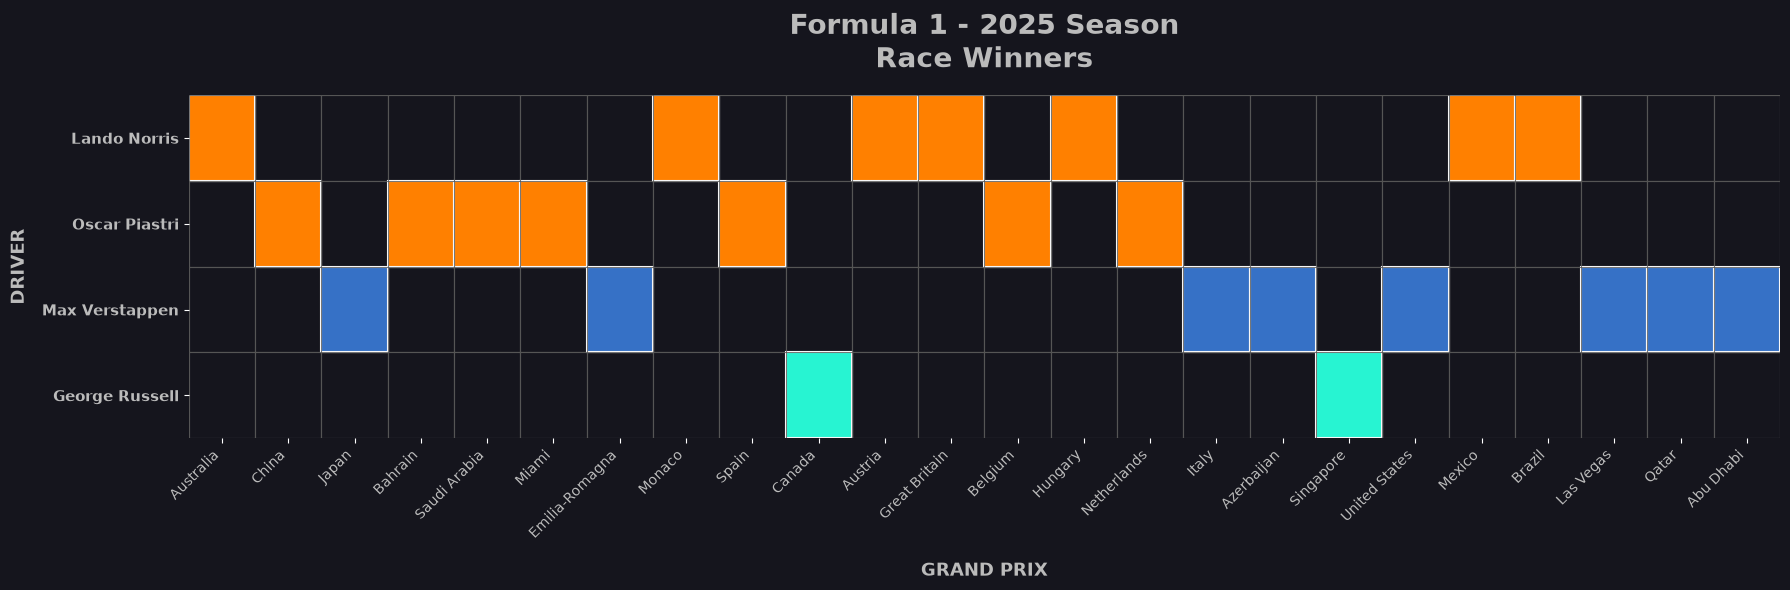

In [19]:
plt.style.use('dark_background')


tracks = race_winners['Track'].tolist()
drivers = race_winners['Driver'].unique().tolist()

fig, ax = plt.subplots(figsize=(18, 6))

ax.set_facecolor('#15151d')
fig.patch.set_facecolor('#15151d')


for row in range(len(drivers)):
    for col in range(len(tracks)):

        ax.add_patch(plt.Rectangle((col, row), 1  ,1, facecolor='#15151d', edgecolor='#555555', linewidth=0.8 ) )


for col, track in enumerate(tracks):

    winner = race_winners[
        race_winners['Track'] == track
    ].iloc[0]

    driver = winner['Driver']
    team = winner['Team']

    row = drivers.index(driver)

    ax.add_patch( Rectangle( (col, row), 1, 1   , facecolor='#202027', edgecolor='#444444', linewidth=1 ) )

    
    ax.add_patch( Rectangle( (col, row),1, 1 , facecolor=team_colors[team], edgecolor='white', linewidth=1.5 ) )



ax.set_xticks( np.arange(len(tracks)) + 0.5)

ax.set_xticklabels( tracks,rotation=45, ha='right', fontsize=10, color='#bbbbbb')


ax.set_yticks( np.arange(len(drivers)) + 0.5)

ax.set_yticklabels( drivers, fontsize=11, fontweight='bold', color='#bbbbbb')



ax.set_xticks( np.arange(len(tracks) + 1), minor=True)

# Horizontal grid lines
ax.set_yticks( np.arange(len(drivers) + 1), minor=True)

ax.grid( which='minor', color='#555555', linestyle='-', linewidth=0.8, alpha=0.8)


ax.tick_params( which='minor', bottom=False, left=False)

ax.set_xlim(0, len(tracks))
ax.set_ylim(0, len(drivers))

ax.invert_yaxis()


ax.set_xlabel( 'GRAND PRIX', fontsize=13, fontweight='bold', color='#bbbbbb', labelpad=15)

ax.set_ylabel( 'DRIVER', fontsize=13, fontweight='bold', color='#bbbbbb', labelpad=10)


ax.set_title( 'Formula 1 - 2025 Season\nRace Winners', fontsize=20, fontweight='bold', color='#bbbbbb', pad=20)


for spine in ax.spines.values():
    spine.set_visible(False)


plt.tight_layout()
plt.show()

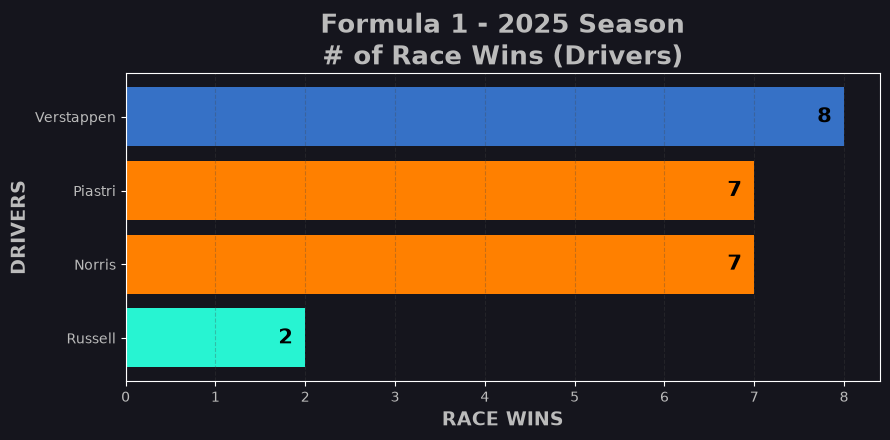

In [32]:
winners = (
    RaceResults[RaceResults['Position'] == '1']['Driver']
    .value_counts().sort_values()
)

# Get colors based on each driver's team
c = []

for driver in winners.index:
    team = RaceResults[
        RaceResults['Driver'] == driver
    ]['Team'].iloc[0]

    c.append(team_colors[team])
    

plt.figure(figsize=(9, 4.5))

plt.gca().set_facecolor('#15151d')
plt.gcf().set_facecolor('#15151d')


plt.barh(
    [driver.split()[1] for driver in winners.index],
    winners,
    color=c
)

# Add number of wins
for i in range(len(winners)):
    plt.text(
        winners.iloc[i] - 0.3,
        i,
        str(winners.iloc[i]),
        fontsize=15,
        fontweight='bold',
        color='black',
        va='center'
    )

plt.title(
    "Formula 1 - 2025 Season\n# of Race Wins (Drivers)",
    fontsize=19,
    fontweight='bold',
    color='#bbbbbb'
)

plt.xlabel(
    'RACE WINS',
    fontsize=14,
    fontweight='bold',
    color='#bbbbbb'
)

plt.ylabel(
    'DRIVERS',
    fontsize=14,
    fontweight='bold',
    color='#bbbbbb'
)

plt.xticks(color='#bbbbbb')
plt.yticks(color='#bbbbbb')

plt.axvline(
    0,
    color='#bbbbbb'
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()

### 2025 Season - Pole Positions ###

In [21]:
pole_positions = (
    QualifyingResults[
        QualifyingResults['Position'] == '1'
    ][['Track', 'Driver', 'Team']]
    .reset_index(drop=True)
    .rename(index=lambda x: x + 1)
)

pole_positions

,Track,Driver,Team
1,Australia,Lando Norris,McLaren Mercedes
2,China,Oscar Piastri,McLaren Mercedes
3,Japan,Max Verstappen,Red Bull Racing Honda RBPT
4,Bahrain,Oscar Piastri,McLaren Mercedes
5,Saudi Arabia,Max Verstappen,Red Bull Racing Honda RBPT
6,Miami,Max Verstappen,Red Bull Racing Honda RBPT
7,Emilia-Romagna,Oscar Piastri,McLaren Mercedes
8,Monaco,Lando Norris,McLaren Mercedes
9,Spain,Oscar Piastri,McLaren Mercedes
10,Canada,George Russell,Mercedes


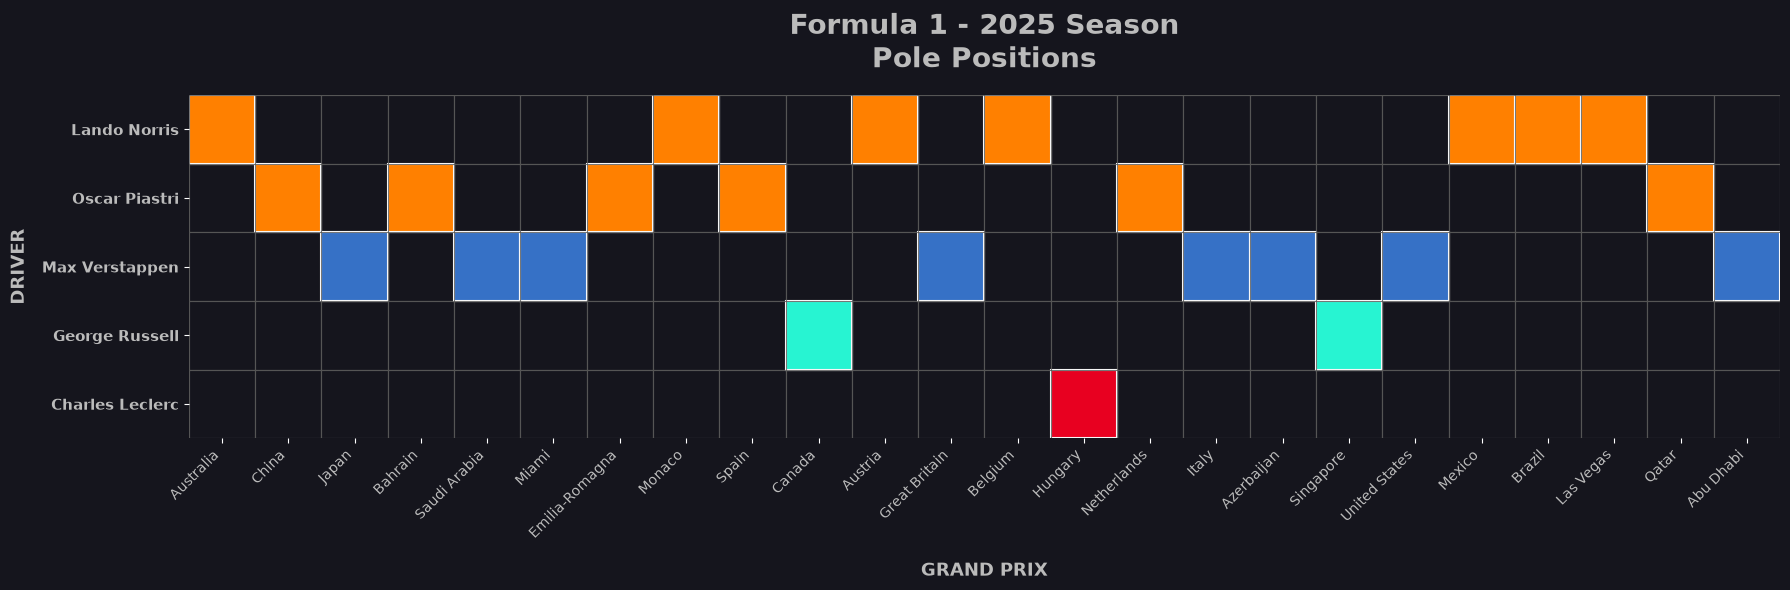

In [22]:
plt.style.use('dark_background')

pole_positions = (
    QualifyingResults[
        QualifyingResults['Position'] == '1'
    ][['Track', 'Driver', 'Team']]
    .reset_index(drop=True)
)


tracks = pole_positions['Track'].tolist()
drivers = pole_positions['Driver'].unique().tolist()

fig, ax = plt.subplots(figsize=(18, 6))

ax.set_facecolor('#15151d')
fig.patch.set_facecolor('#15151d')


for row in range(len(drivers)):
    for col in range(len(tracks)):

        ax.add_patch(plt.Rectangle( (col, row), 1, 1, facecolor='#15151d', edgecolor='#555555', linewidth=0.8 ) )


for col, track in enumerate(tracks):

    pole = pole_positions[
        pole_positions['Track'] == track
    ].iloc[0]

    driver = pole['Driver']
    team = pole['Team']

    row = drivers.index(driver)

    ax.add_patch(plt.Rectangle( (col, row), 1, 1, facecolor='#202027',edgecolor='#444444', linewidth=1 ) )

    ax.add_patch( plt.Rectangle( (col, row), 1, 1, facecolor=team_colors[team], edgecolor='white', linewidth=1.5 ) )


ax.set_xticks( np.arange(len(tracks)) + 0.5)

ax.set_xticklabels(tracks, rotation=45, ha='right', fontsize=10, color='#bbbbbb')


ax.set_yticks( np.arange(len(drivers)) + 0.5)

ax.set_yticklabels(drivers, fontsize=11, fontweight='bold', color='#bbbbbb')


ax.set_xticks( np.arange(len(tracks) + 1), minor=True)

ax.set_yticks( np.arange(len(drivers) + 1), minor=True)

ax.grid( which='minor', color='#555555', linestyle='-', linewidth=0.8, alpha=0.8)


ax.tick_params( which='minor', bottom=False, left=False)


ax.set_xlim( 0, len(tracks))

ax.set_ylim( 0, len(drivers))

ax.invert_yaxis()


ax.set_xlabel( 'GRAND PRIX', fontsize=13, fontweight='bold', color='#bbbbbb',labelpad=15)

ax.set_ylabel( 'DRIVER', fontsize=13, fontweight='bold', color='#bbbbbb', labelpad=10)


ax.set_title( 'Formula 1 - 2025 Season\nPole Positions', fontsize=20, fontweight='bold', color='#bbbbbb', pad=20)


for spine in ax.spines.values():
    spine.set_visible(False)


plt.tight_layout()
plt.show()

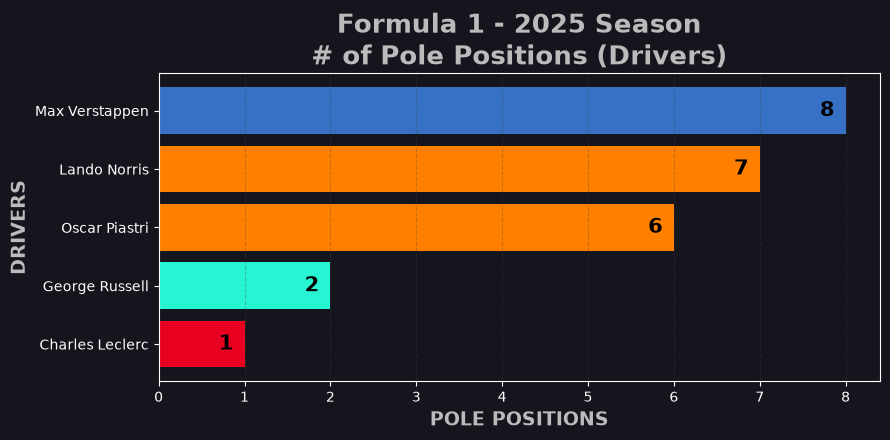

In [23]:
driver_team = ( RaceResults[['Driver', 'Team']] .drop_duplicates('Driver') .set_index('Driver')['Team'])


poles = (pole_positions['Driver'].value_counts().sort_values())

plt.figure(figsize=(9, 4.5))

plt.gca().set_facecolor('#15151d')
plt.gcf().set_facecolor('#15151d')

c = [
    team_colors[driver_team[driver]]
    for driver in poles.index
]

plt.barh(poles.index,poles,color=c)

for i, count in enumerate(poles):
    plt.text(
        count - 0.3,
        i,
        str(count),
        fontsize=15,
        fontweight='bold',
        color='black',
        va='center'
    )

plt.title("Formula 1 - 2025 Season\n# of Pole Positions (Drivers)", fontsize=19, fontweight='bold', color='#bbbbbb')

plt.xlabel('POLE POSITIONS', fontsize=14, fontweight='bold', color='#bbbbbb')

plt.ylabel('DRIVERS', fontsize=14, fontweight='bold', color='#bbbbbb')

plt.grid( axis='x', linestyle='--', alpha=0.3,color='#444444')

plt.tight_layout()
plt.show()

### 2025 Season - Top 10 Finishes (Drivers) ### 

#### Number of point-scoring finishes per driver

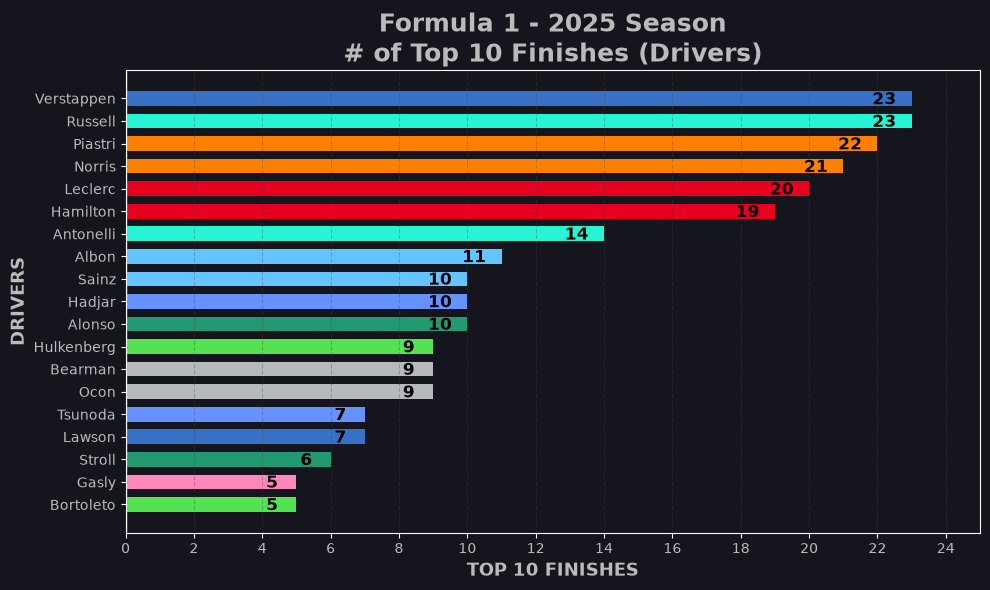

In [27]:
top10Finishes = (
    RaceResults[
        RaceResults['Position'].isin([str(i) for i in range(1, 11)])
    ]['Driver']
    .value_counts()
    .sort_values())


driver_team = (
    RaceResults[['Driver', 'Team']]
    .drop_duplicates('Driver')
    .set_index('Driver')['Team'])

# Assign the correct team color to each driver
c = [
    team_colors[driver_team[driver]]
    for driver in top10Finishes.index]


plt.figure(figsize=(10, 6))

plt.gca().set_facecolor('#15151d')
plt.gcf().set_facecolor('#15151d')

bars = plt.barh([" ".join(driver.split()[1:]) for driver in top10Finishes.index],
    top10Finishes.values,
    color=c,
    height=0.65)


for bar, value in zip(bars, top10Finishes.values):
    plt.text( value - 0.8, bar.get_y() + bar.get_height() / 2.5,
        f"{value:>2}",
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold',
        color='black')

plt.title('Formula 1 - 2025 Season\n# of Top 10 Finishes (Drivers)', fontsize=18, fontweight='bold', color='#bbbbbb')

plt.xlabel('TOP 10 FINISHES', fontsize=13, fontweight='bold', color='#bbbbbb')

plt.ylabel('DRIVERS', fontsize=13, fontweight='bold', color='#bbbbbb')


plt.xlim(0, max(top10Finishes.values) + 2)
plt.xticks(
    range(0, max(top10Finishes.values) + 3, 2),
    color='#bbbbbb')


plt.yticks( color='#bbbbbb', fontsize=10)

plt.axvline(0, color='#bbbbbb', linewidth=1)


plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### 2025 Season - DNF Analysis

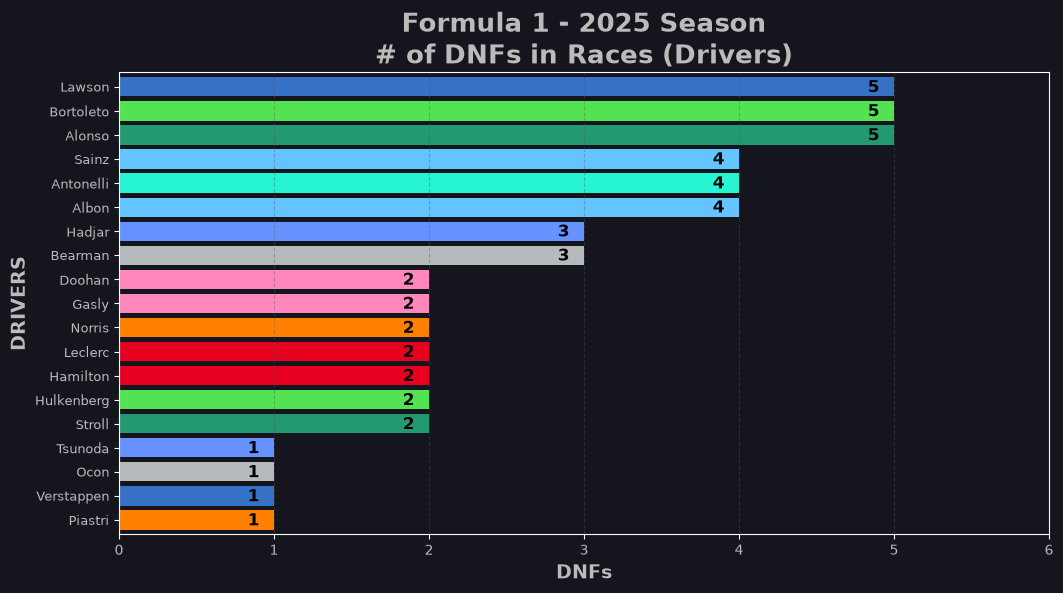

In [28]:
DNFdriver = (
    RaceResults[RaceResults['Time/Retired'] == 'DNF']
    ['Driver']
    .value_counts()
    .sort_values(ascending=False)
)

c = [
    team_colors[driver_team[driver]]
    for driver in DNFdriver.index
]

plt.figure(figsize=(12,6))

plt.gca().set_facecolor('#15151d')
plt.gcf().set_facecolor('#15151d')

plt.axis([
    0,
    DNFdriver.max() + 1,
    len(DNFdriver) - 0.4,
    -0.6
])

plt.barh(
    [driver.split()[1] for driver in DNFdriver.index],
    DNFdriver.values,
    color=c
)

for i, count in enumerate(DNFdriver.values):
    plt.text(
        count - 0.17,
        i + 0.22,
        str(count),
        fontsize=12,
        fontweight='bold',
        color='k'
    )

plt.title(
    'Formula 1 - 2025 Season\n# of DNFs in Races (Drivers)',
    fontsize=19,
    fontweight='bold',
    color='#bbbbbb'
)

plt.xlabel(
    'DNFs',
    fontsize=14,
    fontweight='bold',
    color='#bbbbbb'
)

plt.ylabel(
    'DRIVERS',
    fontsize=14,
    fontweight='bold',
    color='#bbbbbb'
)

plt.xticks(color='#bbbbbb')
plt.yticks(color='#bbbbbb', fontsize=9)

plt.axvline(0, color='#bbbbbb')

plt.grid(
    axis='x',
    linestyle='--',
    color='#555555',
    linewidth=0.8,
    alpha=0.35
)

plt.show()